In [1]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers
from matplotlib import pyplot as plt
import numpy as np
# from keras.preprocessing.image import ImageDataGenerator


2026-02-16 04:20:33.035875: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 04:20:33.049931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-16 04:20:33.074082: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-16 04:20:33.080662: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-16 04:20:33.099549: I tensorflow/core/platform/cpu_feature_guar

In [2]:
devices=tf.config.experimental.list_physical_devices()
devices

I0000 00:00:1771215635.757534   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771215635.873244   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771215635.873285   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
IMG_SIZE = 128   # or whatever you trained with
BATCH_SIZE=32
VAL_SIZE = 10000

RANDOM_SEED=67
tf.random.set_seed(67)
np.random.seed(67)

LABELS = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
print("Train shape:", x_train.shape, y_train.shape)
print("Test  shape:", x_test.shape, y_test.shape)

Train shape: (50000, 32, 32, 3) (50000, 1)
Test  shape: (10000, 32, 32, 3) (10000, 1)


/tmp/ipykernel_60633/1377193937.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"{int(y[j])} - {LABELS[int(y[j])]}")


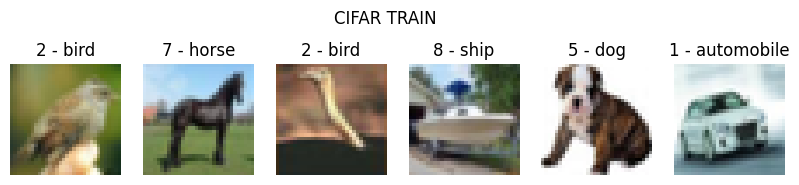

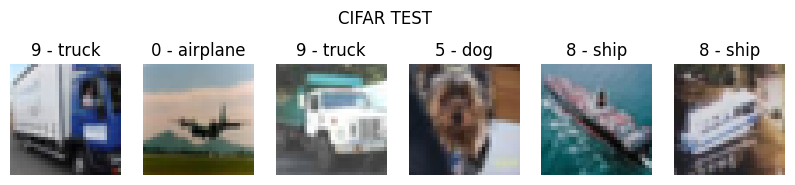

In [4]:
def visualize_data(x, y, title, n=6):
    idx = np.random.choice(len(x), n, replace=False)

    plt.figure(figsize=(10,4))
    for i, j in enumerate(idx):
        plt.subplot(2,6,i+1)
        plt.imshow(x[j], cmap="gray")
        plt.title(f"{int(y[j])} - {LABELS[int(y[j])]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

visualize_data(x_train, y_train, "CIFAR TRAIN")
visualize_data(x_test,  y_test,  "CIFAR TEST")


In [5]:
def class_distribution(y, name):
    y = y.reshape(-1)          # (N,1) -> (N,)
    y = y.astype(int)         # make sure it's integer labels

    counts = np.bincount(y, minlength=10)
    total = len(y)

    print(f"\n{name}")
    for i in range(10):
        print(f"LABEL {i} - {LABELS[i]}: {counts[i]:5d}  ({counts[i]/total:.3f})")
class_distribution(y_train, "TRAIN")
class_distribution(y_test,  "TEST")


TRAIN
LABEL 0 - airplane:  5000  (0.100)
LABEL 1 - automobile:  5000  (0.100)
LABEL 2 - bird:  5000  (0.100)
LABEL 3 - cat:  5000  (0.100)
LABEL 4 - deer:  5000  (0.100)
LABEL 5 - dog:  5000  (0.100)
LABEL 6 - frog:  5000  (0.100)
LABEL 7 - horse:  5000  (0.100)
LABEL 8 - ship:  5000  (0.100)
LABEL 9 - truck:  5000  (0.100)

TEST
LABEL 0 - airplane:  1000  (0.100)
LABEL 1 - automobile:  1000  (0.100)
LABEL 2 - bird:  1000  (0.100)
LABEL 3 - cat:  1000  (0.100)
LABEL 4 - deer:  1000  (0.100)
LABEL 5 - dog:  1000  (0.100)
LABEL 6 - frog:  1000  (0.100)
LABEL 7 - horse:  1000  (0.100)
LABEL 8 - ship:  1000  (0.100)
LABEL 9 - truck:  1000  (0.100)


In [6]:
# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# x_train = x_train.reshape(len(x_train), -1)
# x_test  = x_test.reshape(len(x_test),  -1)

# Labels MUST be integers
y_train = y_train.astype("int32")
y_test  = y_test.astype("int32")


In [7]:

perm = tf.random.shuffle(tf.range(len(x_train)), seed=RANDOM_SEED)

x_train = tf.gather(x_train, perm)
y_train = tf.gather(y_train, perm)

x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

x_train = x_train[:-VAL_SIZE]
y_train = y_train[:-VAL_SIZE]

print("Train:", x_train.shape, y_train.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)


I0000 00:00:1771215637.007036   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771215637.007098   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771215637.007129   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771215637.179710   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771215637.179787   60633 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-16

Train: (40000, 32, 32, 3) (40000, 1)
Val  : (10000, 32, 32, 3) (10000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


In [8]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_val   = tf.keras.utils.to_categorical(y_val, 10)
y_test  = tf.keras.utils.to_categorical(y_test, 10)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000, seed=RANDOM_SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target' (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

In [10]:
model = keras.Sequential([
    keras.Input(shape=(32,32,3)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.3),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.4),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])


# model = tf.keras.models.Sequential([
#     keras.Input(shape=(32,32,3)),

#     keras.layers.Conv2D(8, (3,3), activation='relu', padding='same'),
#     keras.layers.Conv2D(8, (3,3), activation='relu', padding='same'),
#     keras.layers.MaxPooling2D(pool_size=(2,2)),

#     # Block 2
#     keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
#     keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
#     keras.layers.MaxPooling2D(pool_size=(2,2)),

#     # Block 2
#     keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
#     keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
#     keras.layers.MaxPooling2D(pool_size=(2,2)),

#     # Fully connected part
#     keras.layers.Flatten(),
#     keras.layers.Dense(10, activation='softmax')  # 10 classes for CIFAR-10
# ], name="TinyVGG")


In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [13]:

class MetricsStopping(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.85 and logs.get('val_accuracy') > 0.85):
            self.model.stop_training = True
            print("\n\nSufficient Metrics Reached!\n\n")


In [15]:
print("Fit model on training data")
history = model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=MetricsStopping()
)

Fit model on training data
Epoch 1/100


I0000 00:00:1771215659.608341   61017 service.cc:146] XLA service 0x778fe002fd20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771215659.608385   61017 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2026-02-16 04:20:59.679396: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-16 04:21:00.078841: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  38/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1312 - loss: 3.3204

I0000 00:00:1771215663.736010   61017 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3331 - loss: 2.0473

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.3333 - loss: 2.0464 - val_accuracy: 0.5160 - val_loss: 1.3666
Epoch 2/100
   1/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4688 - loss: 1.3238

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5818 - loss: 1.1566 - val_accuracy: 0.6418 - val_loss: 1.0165
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6630 - loss: 0.9658 - val_accuracy: 0.6407 - val_loss: 1.0620
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7051 - loss: 0.8503 - val_accuracy: 0.7160 - val_loss: 0.8080
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7293 - loss: 0.7847 - val_accuracy: 0.7588 - val_loss: 0.6958
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7567 - loss: 0.7037 - val_accuracy: 0.7721 - val_loss: 0.6594
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7758 - loss: 0.6521 - val_accuracy: 0.7913 - val_loss: 0.6029
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7901 - loss: 0.6070 - val_accuracy: 0.7738 - val_loss: 0.6508
Epoch 9/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8071 - loss: 0.5720 - val_

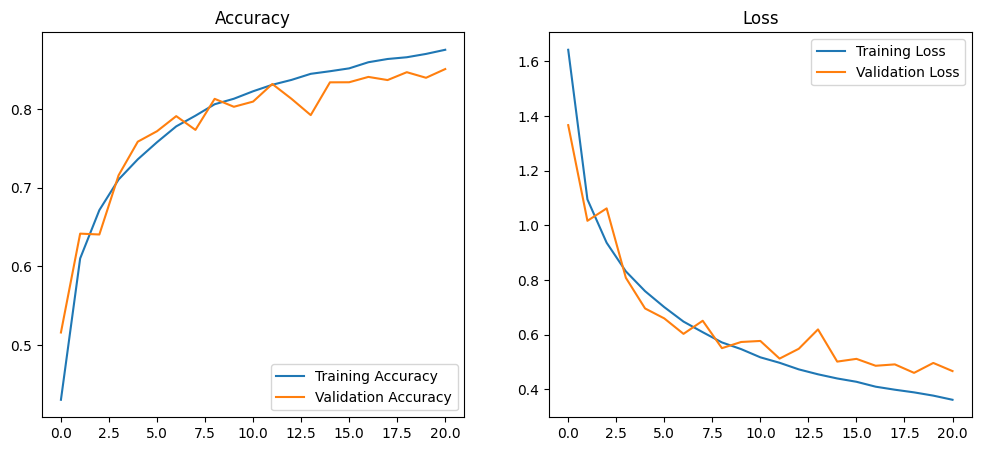

In [17]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Loss")

plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8522 - loss: 0.4736
Test accuracy: 0.8503999710083008


In [ ]:
# model.save("mymodel.h5")